# Analysis of UK Road Safety Data (2024)

**Objective:** To clean, process, and perform an initial exploratory analysis of the UK road casualty data. This notebook demonstrates proficiency in data cleaning with Python's Pandas library.

**By Yassine Malal**
**Date: 19 October 2025**

In [6]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline

## 1. Data Loading and Initial Inspection

First, I will load the `casualties.csv` dataset and perform an initial inspection to understand its structure, size, and potential issues.

In [9]:
# Load the dataset
df_casualties = pd.read_csv('data/casualties.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df_casualties.head())

# Get a summary of the dataset's structure
print("\nDataset Information:")
df_casualties.info()

First 5 rows of the dataset:


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2024010537605,2024,010537605,1,1,1,1,21,5,3,...,0,0,2,4,E01003785,3,1,0.0,1.0,3
1,2024070788497,2024,070788497,2,1,1,1,43,7,3,...,0,0,9,7,E01018742,3,1,0.0,1.0,2
2,2024201441569,2024,201441569,2,1,1,2,28,6,3,...,0,0,9,3,E01009084,3,1,0.0,1.0,1
3,2024351527583,2024,351527583,3,3,1,1,27,6,3,...,0,0,9,3,E01026652,3,1,0.0,1.0,4
4,2024451439906,2024,451439906,1,2,2,2,10,2,3,...,0,0,9,10,E01030839,3,1,0.0,1.0,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128272 entries, 0 to 128271
Data columns (total 23 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   collision_index                     128272 non-null  object 
 1   collision_year                      128272 non-null  int64  
 2   collision_ref_no                    128272 non-null  object 
 3   vehicle_reference                   128272 non-null  int64  
 4   casualty_reference                  128272 non-null  int64  
 5   casualty_class                      128272 non-null  int64  
 6   sex_of_casualty                     128272 non-null  int64  
 7   age_of_casualty                     128272 non-null  int64  
 8   age_band_of_casualty                128272 non-null  int64  
 9   casualty_severity                   128272 non-null  int64  
 10  pedestrian_location                 128272 non-null  int64  
 11  pede

## 2. Data Cleaning

From the initial inspection, several columns contain `-1` or `9` which often represent 'missing' or 'unknown' data in these datasets. I will also check for standard missing values (`NaN`) and assess data types.

My cleaning process will involve:
1.  Checking the percentage of missing values.
2.  Replacing placeholder values like `-1` with a proper `NaN` (Not a Number) for easier handling.
3.  Converting columns to more appropriate data types (e.g., categorical).

In [14]:
# Check for null values
print("Missing values per column (before cleaning):")
print(df_casualties.isnull().sum())

# Let's inspect a column that might have placeholder -1 values, like 'age_of_casualty'
print("\nValue counts for 'age_of_casualty' (before cleaning):")
# We use .get(-1, 0) to show the count of -1, which will be 0 if none exist
print(f"Number of '-1' values: {df_casualties['age_of_casualty'].value_counts().get(-1, 0)}")

# --- CORRECTED LINE BELOW ---
# Replace -1 with a proper missing value format (pd.NA)
df_casualties['age_of_casualty'] = df_casualties['age_of_casualty'].replace(-1, pd.NA)

print("\nCleaning complete. The FutureWarning should now be gone.")

# Now, let's calculate the average age, ignoring the missing values
average_age = df_casualties['age_of_casualty'].mean()
print(f"\nThe average age of a casualty (after cleaning) is: {average_age:.2f} years")

Missing values per column (before cleaning):
collision_index                          0
collision_year                           0
collision_ref_no                         0
vehicle_reference                        0
casualty_reference                       0
casualty_class                           0
sex_of_casualty                          0
age_of_casualty                       2552
age_band_of_casualty                     0
casualty_severity                        0
pedestrian_location                      0
pedestrian_movement                      0
car_passenger                            0
bus_or_coach_passenger                   0
pedestrian_road_maintenance_worker       0
casualty_type                            0
casualty_imd_decile                      0
lsoa_of_casualty                         0
enhanced_casualty_severity               0
casualty_injury_based                    0
casualty_adjusted_severity_serious       0
casualty_adjusted_severity_slight        0
casualty_

## 3. Exploratory Data Analysis (EDA)

Now that the data is cleaner, I can perform some basic analysis to find insights. I'll create a simple visualisation to show the distribution of casualty severity.

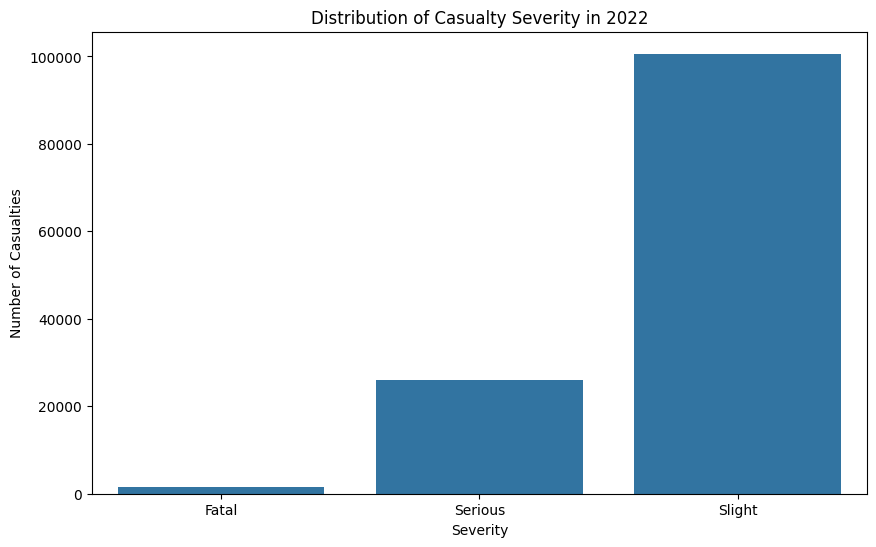

In [13]:
# Map numerical severity to readable labels
casualty_severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
df_casualties['casualty_severity_label'] = df_casualties['casualty_severity'].map(casualty_severity_map)

# Create a count plot
plt.figure(figsize=(10, 6))
sns.countplot(x='casualty_severity_label', data=df_casualties, order=['Fatal', 'Serious', 'Slight'])
plt.title('Distribution of Casualty Severity in 2022')
plt.xlabel('Severity')
plt.ylabel('Number of Casualties')
plt.show()